**AI And ML**

**Student Id:** 2417514

**Student Name**: Suvina Thapa

Workshop 5


In [45]:
from tensorflow.keras.layers import Conv2D

layer = Conv2D(
    filters=32,
    kernel_size=(3,3),
    strides=(1,1),
    padding="valid",
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform"
)

In [46]:
#Syntax of Pooling Layers
from tensorflow.keras.layers import MaxPooling2D, AveragePooling2D
max_pool = MaxPooling2D(pool_size=(2,2), strides=None, padding="valid")
avg_pool = AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9600 - loss: 0.1283 - val_accuracy: 0.9850 - val_loss: 0.0430
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9867 - loss: 0.0412 - val_accuracy: 0.9899 - val_loss: 0.0292
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 23ms/step - accuracy: 0.9909 - loss: 0.0273 - val_accuracy: 0.9870 - val_loss: 0.0398
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9935 - loss: 0.0207 - val_accuracy: 0.9920 - val_loss: 0.0248
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9909 - val_loss: 0.0291
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9909 - loss: 0.0291
Test accuracy: 0.9909
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


#7 Exercise
Implement an End to End CNN Model for Image CLassification Task



In [48]:
#import library
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split


#Uploading and extracting the datatset zip
from google.colab import drive
import zipfile, os

# Mount your Drive
drive.mount('/content/drive')

# Extract directly from Drive — no re-upload needed ever again
zip_path = "/content/drive/MyDrive/AI And ML/Week5/FruitinAmazon.zip"

if not os.path.exists("dataset"):
    os.makedirs("dataset")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("dataset/")

print("Extracted successfully!")

# Auto-find train/ and test/
def find_subdir(root, name):
    for dirpath, dirnames, _ in os.walk(root):
        if name in dirnames:
            return os.path.join(dirpath, name)
    return None

train_dir = find_subdir("dataset", "train")
test_dir  = find_subdir("dataset", "test")
print(f"Train: {train_dir}")
print(f"Test:  {test_dir}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted successfully!
Train: dataset/FruitinAmazon/train
Test:  dataset/FruitinAmazon/test


TASK 1a: Visualising sample images per class
*********************************************
Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



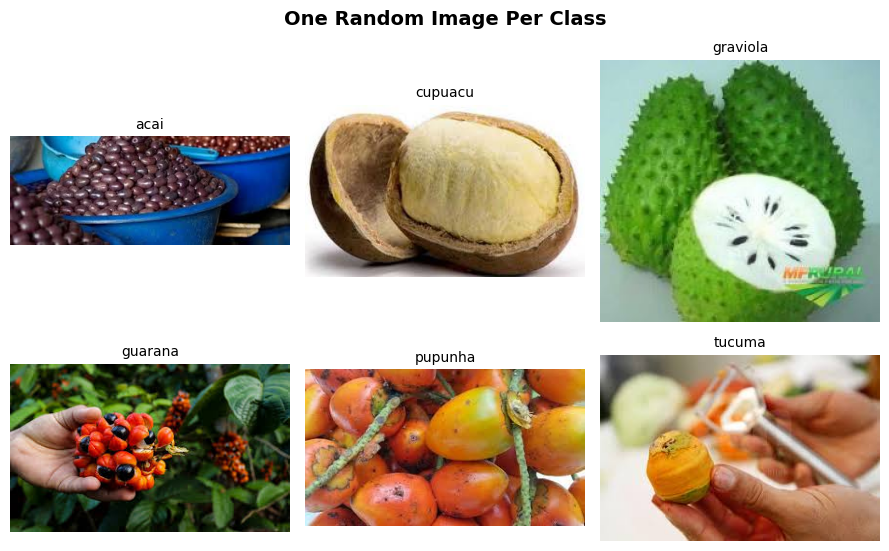

In [49]:
#Task1 Visualizing one random image per class
print("TASK 1a: Visualising sample images per class")
print("*" * 45)
# Get sorted list of class folder names
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
print(f"Classes found: {class_dirs}\n")

#Selecting one image randomly from each clas
sample_images = []
sample_labels = []
for cls in class_dirs:
  cls_path = os.path.join(train_dir, cls)
  all_images = [
      f for f in os.listdir(cls_path)
      if f.lower().endswith((".jpeg"))
  ]
  if all_images:
    choosen = random.choice(all_images)
    sample_images.append(os.path.join(cls_path, choosen))
    sample_labels.append(cls)

#plotting in 2 grid row
num_images = len(sample_images)
#Division for euqal columns
num_cols = (num_images + 1) // 2
num_rows = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, 6))
axes = axes.flatten()

for i, (image_path, label) in enumerate(zip(sample_images, sample_labels)):
  img = Image.open(image_path).convert("RGB")
  axes[i].imshow(img)
  axes[i].set_title(label, fontsize=10)
  axes[i].axis("off")

# Turing off any empty sub plot axis
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("One Random Image Per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("task1_sample_images.png", dpi=150)
plt.show()







#task1a Observation

-> Images of jpeg belong to different visual fruit class and image vary in sizes,background and lighting condition which shows the need of resizing and normalization.

In [50]:
#Task 1b Checking for and removing corrupted images
print("TASK 1b: Checking for corrupted images")
print("*" * 45)

#List to track all corrupted images
corrupted_images = []
for cls in class_dirs:
  cls_path = os.path.join(train_dir, cls)
  for fname in os.listdir(cls_path):
    if not fname.lower().endswith(('.jpeg')):
      continue

    image_path = os.path.join(cls_path, fname)
    try:
      with Image.open(image_path) as img:
        #verifying file integreity
        img.verify()
    except(IOError, SyntaxError) as e:
      print(f"Invalid image: {image_path}")

if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal removed: {len(corrupted_images)}")
print()



TASK 1b: Checking for corrupted images
*********************************************
No Corrupted Images Found.



In [51]:
#Task2 Loading and Preprocessing Image data in keras
print("TASK 2: Loading and Preprocessing Image data in Keras")
print("*" * 45)

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

#Normalization by dividing every pixel by 255
rescale = tf.keras.layers.Rescaling(1./255)

#Training Datatset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels = 'inferred', label_mode = 'int', image_size = (img_height, img_width),
    interpolation = 'nearest', batch_size = batch_size, shuffle = True, validation_split = validation_split, subset = 'training', seed = 123
)
class_names = train_ds.class_names
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

#Validation datatset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels = 'inferred', label_mode = 'int', image_size = (img_height, img_width),
    interpolation = 'nearest', batch_size = batch_size, shuffle = False, validation_split = validation_split, subset = 'validation', seed = 123)
val_ds = val_ds.map(lambda x, y:(rescale(x), y))

#Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, labels = 'inferred', label_mode = 'int',image_size= (img_height, img_width),interpolation = 'nearest',batch_size    = batch_size,
    shuffle = False,seed = 123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Class names are inferred from folder names (same order as integer labels)

num_classes = len(class_names)
print(f"Classes : {class_names}")
print(f"Total   : {num_classes} classes\n")


TASK 2: Loading and Preprocessing Image data in Keras
*********************************************
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total   : 6 classes



In [52]:
#Task3 Implementing CNN
print("TASK 3: Building the CNN")
print("=" * 35)

model = tf.keras.Sequential([

    # Convolutional Layer 1 + ReLU activation + Pooling Layer 1
    tf.keras.layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        strides     = (1, 1),
        padding     = 'same',
        activation  = 'relu',
        input_shape = (img_height, img_width, 3)
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # Convolutional Layer 2 + ReLU activation + Pooling Layer 2
    tf.keras.layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        strides     = (1, 1),
        padding     = 'same',
        activation  = 'relu'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
      # Flatten layer
    tf.keras.layers.Flatten(),

    # Hidden Layer 1 – 64 neurons
    tf.keras.layers.Dense(64, activation='relu'),

    # Hidden Layer 2 – 128 neurons
    tf.keras.layers.Dense(128, activation='relu'),

    # Output Layer – one neuron per class (raw logits)
    tf.keras.layers.Dense(num_classes)
])

model.summary()
print()

TASK 3: Building the CNN


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

TASK 4: Compiling the model
Model compiled.

 Training the model
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.1535 - loss: 1.9120
Epoch 1: val_loss improved from None to 1.99387, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.1944 - loss: 1.8940 - val_accuracy: 0.0000e+00 - val_loss: 1.9939
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2566 - loss: 1.7183
Epoch 2: val_loss improved from 1.99387 to 1.63799, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.2778 - loss: 1.6803 - val_accuracy: 0.4444 - val_loss: 1.6380
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5330 - loss: 1.4860
Epoch 3: val_loss improved from 1.63799 to 1.39406, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.5139 - loss: 1.4139 - val_accuracy: 0.6667 - val_loss: 1.3941
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5684 - loss: 1.2143
Epoch 4: val_loss improved from 1.39406 to 1.22936, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.5972 - loss: 1.1961 - val_accuracy: 0.7222 - val_loss: 1.2294
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7038 - loss: 0.9379
Epoch 5: val_loss improved from 1.22936 to 0.74563, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step - accuracy: 0.7639 - loss: 0.8855 - val_accuracy: 0.8333 - val_loss: 0.7456
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9194 - loss: 0.5638
Epoch 6: val_loss did not improve from 0.74563
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - accuracy: 0.8889 - loss: 0.5837 - val_accuracy: 0.7778 - val_loss: 0.8387
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8941 - loss: 0.4282
Epoch 7: val_loss improved from 0.74563 to 0.27914, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 242ms/step - accuracy: 0.8611 - loss: 0.4914 - val_accuracy: 0.9444 - val_loss: 0.2791
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9719 - loss: 0.3101
Epoch 8: val_loss did not improve from 0.27914
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.9583 - loss: 0.2804 - val_accuracy: 0.7778 - val_loss: 0.6919
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9535 - loss: 0.1497
Epoch 9: val_loss did not improve from 0.27914
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.9444 - loss: 0.1706 - val_accuracy: 0.8889 - val_loss: 0.3040
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9941 - loss: 0.0717
Epoch 10: val_loss did not improve from 0.27914
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.9861 - loss: 0.0873 - val_accuracy: 0.8333 - val_loss: 0.4645
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9899 - loss: 0.0709
Epoch 1


Epoch 12: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.9722 - loss: 0.0956 - val_accuracy: 0.8333 - val_loss: 0.2790
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 1.0000 - loss: 0.0303
Epoch 13: val_loss improved from 0.27904 to 0.22715, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 1.0000 - loss: 0.0292 - val_accuracy: 0.9444 - val_loss: 0.2272
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 1.0000 - loss: 0.0169
Epoch 14: val_loss did not improve from 0.22715
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 1.0000 - loss: 0.0149 - val_accuracy: 0.9444 - val_loss: 0.2336
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 1.0000 - loss: 0.0069
Epoch 15: val_loss did not improve from 0.22715
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 0.8889 - val_loss: 0.2860
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 1.0000 - loss: 0.0070
Epoch 16: val_loss did not improve from 0.22715
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.8333 - val_loss: 0.3717
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 1.0000 - loss: 0.0053
Ep

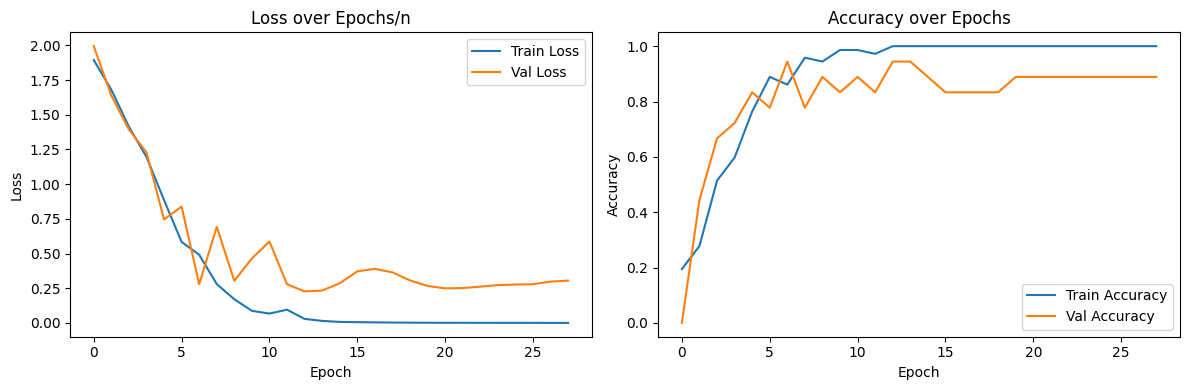

Training curves saved → task4_training_curves.png



In [53]:
#Task4 Compliling Mode
print("TASK 4: Compiling the model")
print("=" * 35)

model.compile(
    optimizer = 'adam',
    loss      = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics   = ['accuracy']
)
print("Model compiled.\n")

print(" Training the model")
print("=" * 35)

# Reload datasets with batch_size = 16 as required
train_ds16 = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = 16,
    shuffle          = True,
    validation_split = validation_split,
    subset           = 'training',
    seed             = 123
)
train_ds16 = train_ds16.map(lambda x, y: (rescale(x), y))

val_ds16 = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = 16,
    shuffle          = False,
    validation_split = validation_split,
    subset           = 'validation',
    seed             = 123
)
val_ds16 = val_ds16.map(lambda x, y: (rescale(x), y))

callbacks = [
    # Save the model only when val_loss improves
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = 'best_model.h5',
        monitor        = 'val_loss',
        save_best_only = True,
        verbose        = 1
    ),
    # Stop training if val_loss does not improve for 15 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor              = 'val_loss',
        patience             = 15,
        verbose              = 1,
        restore_best_weights = True
    )
]

history = model.fit(
    train_ds16,
    validation_data = val_ds16,
    epochs          = 250,
    callbacks       = callbacks
)

# Plot training and validation loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss over Epochs/n')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'],     label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig("task4_training_curves.png", dpi=150)
plt.show()
print("Training curves saved → task4_training_curves.png\n")

Observation:

The graphs illustrate the training performance of the fruit classification model over multiple epochs by comparing training and validation accuracy and loss.

In the accuracy graph, the training accuracy steadily increases from around 20% and eventually reaches nearly 100%, indicating that the model learns the training data very effectively over time. The validation accuracy also improves significantly during the early epochs and stabilizes around 85%–95%, showing that the model performs well on unseen validation data. However, some fluctuations in validation accuracy suggest minor instability during learning.

 In the loss graph, both training and validation loss decrease rapidly during the initial epochs, indicating successful learning and optimization of the model. The training loss continues to drop close to zero, while the validation loss decreases initially but later fluctuates and slightly increases after certain epochs. This pattern suggests that the model may be experiencing slight overfitting, where it performs extremely well on training data but begins to memorize the training set rather than generalizing perfectly to new data.

 Overall, the model demonstrates strong learning performance with high accuracy, though the divergence between training and validation metrics indicates the possibility of overfitting in later epochs.

In [54]:
#Task 5 Evaluating the Model on Test set
print("TASK 5: Evaluating on the test set")
print("=" * 35)

test_ds16 = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (img_height, img_width),
    interpolation = 'nearest',
    batch_size    = 16,
    shuffle       = False,
    seed          = 123
)
test_ds16 = test_ds16.map(lambda x, y: (rescale(x), y))

test_loss, test_acc = model.evaluate(test_ds16, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%\n")

TASK 5: Evaluating on the test set
Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6667 - loss: 0.9889

Test Loss     : 0.9889
Test Accuracy : 66.67%



In [55]:
#Task 6: Saving and load the Model
print("TASK 6: Saving and loading the model")
print("=" * 35)

# Save
model.save('final_model.h5')
print("Model saved → final_model.h5")

# Load
loaded_model = tf.keras.models.load_model('final_model.h5')
print("Model loaded successfully.")

# Re-evaluate with loaded model (should give identical results)
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds16, verbose=1)
print(f"\nTest Loss     : {loaded_loss:.4f}")
print(f"Test Accuracy : {loaded_acc * 100:.2f}%\n")


TASK 6: Saving and loading the model
Model saved → final_model.h5


Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6667 - loss: 0.9889 

Test Loss     : 0.9889
Test Accuracy : 66.67%



TASK 7: Predictions & Classification Report



Classification Report:

              precision    recall  f1-score   support

        acai       0.50      0.80      0.62         5
     cupuacu       0.40      0.80      0.53         5
    graviola       1.00      0.40      0.57         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.67        30
   macro avg       0.82      0.67      0.68        30
weighted avg       0.82      0.67      0.68        30



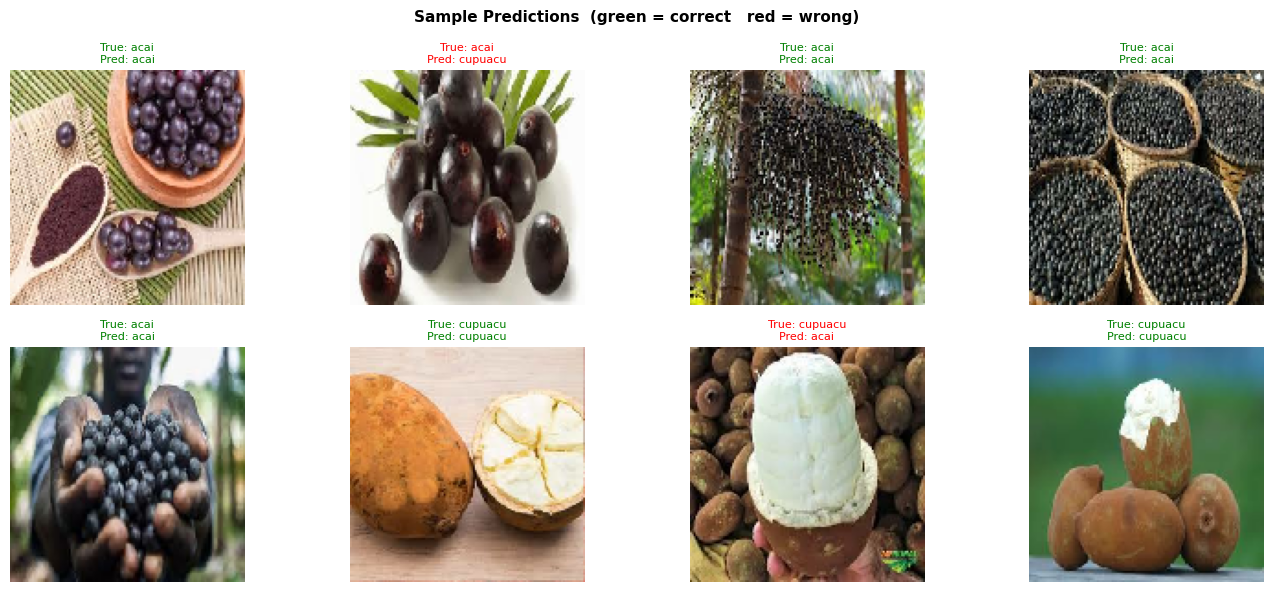


Predictions saved as task7_predictions.png


In [56]:
#Task7 Predictions and Classifcation
from sklearn.metrics import classification_report
print("TASK 7: Predictions & Classification Report")
print("=" * 45)

all_preds  = []
all_labels = []

for images, labels in test_ds16:
    # Get raw logits from model
    logits = loaded_model.predict(images, verbose=0)
    # Convert logits to predicted class labels
    preds  = np.argmax(logits, axis=1)
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Print Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds,target_names = class_names
))
# Show 8 sample predictions visually (green = correct, red = wrong)
sample_imgs = []
sample_true = []
sample_pred = []

for images, labels in test_ds16.take(1):
    logits = loaded_model.predict(images, verbose=0)
    preds  = np.argmax(logits, axis=1)
    for i in range(min(8, len(images))):
        sample_imgs.append(images[i].numpy())
        sample_true.append(class_names[labels[i]])
        sample_pred.append(class_names[preds[i]])

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i in range(len(sample_imgs)):
    axes[i].imshow(sample_imgs[i])
    colour = "green" if sample_true[i] == sample_pred[i] else "red"
    axes[i].set_title(
        f"True: {sample_true[i]}\nPred: {sample_pred[i]}",
        color=colour, fontsize=8
    )
    axes[i].axis("off")

plt.suptitle("Sample Predictions  (green = correct   red = wrong)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("\ntask7_predictions.png", dpi=150)
plt.show()
print("\nPredictions saved as task7_predictions.png")

